# 16. Final Model Comparison

## Objective

This notebook consolidates the experimental results from:

1. Classical Machine Learning
   - Logistic Regression
   - SVM
   - Random Forest

2. Deep Learning — Cycle Level
   - Lightweight Mel CNN
   - Multi-feature CNN
   - Multi-feature CNN (12B)
   - CNN-LSTM

3. Deep Learning — Patient Level
   - Majority-vote aggregation
   - Mean-probability aggregation

The purpose is to identify the strongest model under the appropriate
evaluation protocol and summarize the complete experimental findings.

### Evaluation Protocols

The classical ML experiments and deep-learning experiments used different
test protocols. Therefore, their metrics are reported separately rather
than being treated as directly comparable rankings.

- Classical ML: official ICBHI cycle-level test split
- Deep Learning: patient-disjoint cycle-level test split
- Patient-level: aggregation of predictions across cycles belonging
  to each patient

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("/Users/vs/Sem 5/Respiratory-Disease-Classification")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

CLASSICAL_DIR = PROCESSED_DIR / "classical_ml"
DL_DIR = PROCESSED_DIR / "deep_learning"
PATIENT_DIR = DL_DIR / "patient_level_prediction"

print("Project root:", PROJECT_ROOT)
print("Classical ML directory:", CLASSICAL_DIR)
print("Deep learning directory:", DL_DIR)
print("Patient-level directory:", PATIENT_DIR)

Project root: /Users/vs/Sem 5/Respiratory-Disease-Classification
Classical ML directory: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/classical_ml
Deep learning directory: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning
Patient-level directory: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/patient_level_prediction


In [2]:
print("Classical ML output files:\n")

for path in sorted(CLASSICAL_DIR.iterdir()):
    print(path.name)

Classical ML output files:

.ipynb_checkpoints
classical_ml_model_comparison.csv
classical_ml_per_disease_results.csv
classical_ml_predictions.csv
classical_ml_selected_features.csv
random_forest_feature_group_importance.csv
random_forest_feature_importance.csv


In [3]:
# Find likely metric/result files generated by previous notebooks

candidate_files = []

for base_dir in [CLASSICAL_DIR, DL_DIR, PATIENT_DIR]:
    if base_dir.exists():
        for path in sorted(base_dir.rglob("*")):
            if path.is_file() and path.suffix.lower() in [".csv", ".json"]:
                name = path.name.lower()
                if any(term in name for term in [
                    "metric",
                    "result",
                    "summary",
                    "comparison",
                    "prediction"
                ]):
                    candidate_files.append(path)

for path in candidate_files:
    print(path.relative_to(PROJECT_ROOT))

data/processed/classical_ml/.ipynb_checkpoints/classical_ml_model_comparison-checkpoint.csv
data/processed/classical_ml/.ipynb_checkpoints/classical_ml_per_disease_results-checkpoint.csv
data/processed/classical_ml/classical_ml_model_comparison.csv
data/processed/classical_ml/classical_ml_per_disease_results.csv
data/processed/classical_ml/classical_ml_predictions.csv
data/processed/deep_learning/cnn_baseline/cnn_baseline_experiment_summary.csv
data/processed/deep_learning/cnn_baseline/cnn_baseline_metrics.csv
data/processed/deep_learning/cnn_baseline/cnn_split_summary.csv
data/processed/deep_learning/cnn_baseline/cnn_test_predictions.csv
data/processed/deep_learning/cnn_lstm/cnn_lstm_experiment_summary.json
data/processed/deep_learning/cnn_lstm/cnn_lstm_metrics.csv
data/processed/deep_learning/cnn_lstm/cnn_lstm_test_predictions.csv
data/processed/deep_learning/cnn_lstm/cnn_model_comparison.csv
data/processed/deep_learning/multifeature_cnn/cnn_baseline_vs_multifeature_comparison.csv
da

In [4]:
classical_csv_files = sorted(CLASSICAL_DIR.glob("*.csv"))

print("Classical ML CSV files:")
for i, path in enumerate(classical_csv_files, start=1):
    print(f"{i}. {path.name}")

Classical ML CSV files:
1. classical_ml_model_comparison.csv
2. classical_ml_per_disease_results.csv
3. classical_ml_predictions.csv
4. classical_ml_selected_features.csv
5. random_forest_feature_group_importance.csv
6. random_forest_feature_importance.csv


In [5]:
for path in classical_csv_files:
    try:
        df_temp = pd.read_csv(path)
        print("\n" + "=" * 70)
        print(path.name)
        print("Shape:", df_temp.shape)
        print("Columns:", list(df_temp.columns))
        print(df_temp.head(3))
    except Exception as e:
        print(f"\nCould not read {path.name}: {e}")


classical_ml_model_comparison.csv
Shape: (3, 8)
Columns: ['model', 'accuracy', 'balanced_accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1', 'roc_auc_ovr_macro']
                 model  accuracy  balanced_accuracy  macro_precision  \
0        Random Forest  0.874456           0.426495         0.370614   
1                  SVM  0.806604           0.458256         0.260503   
2  Logistic Regression  0.641509           0.411920         0.233807   

   macro_recall  macro_f1  weighted_f1  roc_auc_ovr_macro  
0      0.266559  0.279604     0.877536                NaN  
1      0.286410  0.265580     0.847078                NaN  
2      0.257450  0.218218     0.745795                NaN  

classical_ml_per_disease_results.csv
Shape: (24, 6)
Columns: ['model', 'disease', 'precision', 'recall', 'f1_score', 'support']
                 model         disease  precision    recall  f1_score  support
0  Logistic Regression          Asthma   0.000000  0.000000   0.00000        0


In [6]:
dl_csv_files = sorted(DL_DIR.rglob("*.csv"))

print("Deep-learning CSV files:")
for i, path in enumerate(dl_csv_files, start=1):
    print(f"{i}. {path.relative_to(PROJECT_ROOT)}")

Deep-learning CSV files:
1. data/processed/deep_learning/cnn_baseline/cnn_baseline_experiment_summary.csv
2. data/processed/deep_learning/cnn_baseline/cnn_baseline_metrics.csv
3. data/processed/deep_learning/cnn_baseline/cnn_patient_disjoint_manifest.csv
4. data/processed/deep_learning/cnn_baseline/cnn_split_summary.csv
5. data/processed/deep_learning/cnn_baseline/cnn_test_predictions.csv
6. data/processed/deep_learning/cnn_baseline/cnn_training_class_weights.csv
7. data/processed/deep_learning/cnn_baseline/cnn_training_history.csv
8. data/processed/deep_learning/cnn_baseline/test_cnn_manifest.csv
9. data/processed/deep_learning/cnn_baseline/train_cnn_manifest.csv
10. data/processed/deep_learning/cnn_baseline/validation_cnn_manifest.csv
11. data/processed/deep_learning/cnn_lstm/cnn_lstm_confusion_matrix.csv
12. data/processed/deep_learning/cnn_lstm/cnn_lstm_metrics.csv
13. data/processed/deep_learning/cnn_lstm/cnn_lstm_test_predictions.csv
14. data/processed/deep_learning/cnn_lstm/cnn_

In [7]:
dl_csv_files = sorted(DL_DIR.rglob("*.csv"))

print("Deep-learning CSV files:")
for i, path in enumerate(dl_csv_files, start=1):
    print(f"{i}. {path.relative_to(PROJECT_ROOT)}")

Deep-learning CSV files:
1. data/processed/deep_learning/cnn_baseline/cnn_baseline_experiment_summary.csv
2. data/processed/deep_learning/cnn_baseline/cnn_baseline_metrics.csv
3. data/processed/deep_learning/cnn_baseline/cnn_patient_disjoint_manifest.csv
4. data/processed/deep_learning/cnn_baseline/cnn_split_summary.csv
5. data/processed/deep_learning/cnn_baseline/cnn_test_predictions.csv
6. data/processed/deep_learning/cnn_baseline/cnn_training_class_weights.csv
7. data/processed/deep_learning/cnn_baseline/cnn_training_history.csv
8. data/processed/deep_learning/cnn_baseline/test_cnn_manifest.csv
9. data/processed/deep_learning/cnn_baseline/train_cnn_manifest.csv
10. data/processed/deep_learning/cnn_baseline/validation_cnn_manifest.csv
11. data/processed/deep_learning/cnn_lstm/cnn_lstm_confusion_matrix.csv
12. data/processed/deep_learning/cnn_lstm/cnn_lstm_metrics.csv
13. data/processed/deep_learning/cnn_lstm/cnn_lstm_test_predictions.csv
14. data/processed/deep_learning/cnn_lstm/cnn_

In [8]:
for path in dl_csv_files:
    name = path.name.lower()

    if any(term in name for term in ["metric", "comparison", "summary"]):
        try:
            df_temp = pd.read_csv(path)

            print("\n" + "=" * 70)
            print(path.relative_to(PROJECT_ROOT))
            print("Shape:", df_temp.shape)
            print("Columns:", list(df_temp.columns))
            print(df_temp.head(5))

        except Exception as e:
            print(f"\nCould not read {path.name}: {e}")


data/processed/deep_learning/cnn_baseline/cnn_baseline_experiment_summary.csv
Shape: (1, 16)
Columns: ['experiment', 'input', 'input_shape', 'split_strategy', 'augmentation', 'class_weights', 'model_selection', 'early_stopping', 'test_patients', 'test_cycles', 'accuracy', 'balanced_accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1']
                     experiment                input   input_shape  \
0  Lightweight Mel CNN Baseline  Log-Mel spectrogram  (1, 64, 157)   

     split_strategy                                augmentation  \
0  Patient-disjoint  Training only: Gaussian noise + time shift   

   class_weights  model_selection   early_stopping  test_patients  \
0  Training only  Validation loss  Validation loss             25   

   test_cycles  accuracy  balanced_accuracy  macro_precision  macro_recall  \
0         1561  0.716848           0.310168         0.213023      0.265858   

   macro_f1  weighted_f1  
0   0.21288     0.768721  

data/processed/d

In [9]:
PATIENT_COMPARISON_PATH = (
    PATIENT_DIR / "patient_aggregation_comparison.csv"
)

patient_comparison_df = pd.read_csv(PATIENT_COMPARISON_PATH)

print("Shape:", patient_comparison_df.shape)
display(patient_comparison_df)

Shape: (2, 8)


,rank,aggregation_method,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,Majority Vote,0.56,0.333333,0.132812,0.25,0.162069,0.482207
1,2,Mean Probability,0.56,0.333333,0.132812,0.25,0.162069,0.482207


In [10]:
PATIENT_SUMMARY_PATH = (
    PATIENT_DIR / "patient_level_experiment_summary.json"
)

with open(PATIENT_SUMMARY_PATH, "r") as f:
    patient_summary = json.load(f)

print(json.dumps(patient_summary, indent=2))

{
  "experiment": "Patient-level prediction",
  "base_model": "Lightweight Mel CNN",
  "test_patients": 25,
  "test_cycles": 1561,
  "aggregation_methods": [
    "Majority Vote",
    "Mean Probability"
  ],
  "best_aggregation_method": "Majority Vote",
  "best_macro_f1": 0.16206896551724137,
  "best_balanced_accuracy": 0.3333333333333333,
  "patient_disjoint_evaluation": true
}


In [11]:
dl_results = pd.DataFrame([
    {
        "Model": "Lightweight Mel CNN",
        "Accuracy": 0.716848,
        "Balanced Accuracy": 0.310168,
        "Macro Precision": 0.213023,
        "Macro Recall": 0.265858,
        "Macro F1": 0.212880,
        "Weighted F1": 0.768721,
    },
    {
        "Model": "Multi-feature CNN (12A)",
        "Accuracy": 0.855221,
        "Balanced Accuracy": 0.166417,
        "Macro Precision": 0.142720,
        "Macro Recall": 0.166417,
        "Macro F1": 0.153660,
        "Weighted F1": 0.789662,
    },
    {
        "Model": "Multi-feature CNN (12B)",
        "Accuracy": 0.856502,
        "Balanced Accuracy": 0.166667,
        "Macro Precision": 0.142750,
        "Macro Recall": 0.166667,
        "Macro F1": 0.153784,
        "Weighted F1": 0.790299,
    },
    {
        "Model": "CNN-LSTM",
        "Accuracy": 0.813581,
        "Balanced Accuracy": 0.226085,
        "Macro Precision": 0.134473,
        "Macro Recall": 0.169564,
        "Macro F1": 0.146471,
        "Weighted F1": 0.786735,
    },
])

display(dl_results)

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Lightweight Mel CNN,0.716848,0.310168,0.213023,0.265858,0.212880,0.768721
1,Multi-feature CNN (12A),0.855221,0.166417,0.142720,0.166417,0.153660,0.789662
2,Multi-feature CNN (12B),0.856502,0.166667,0.142750,0.166667,0.153784,0.790299
3,CNN-LSTM,0.813581,0.226085,0.134473,0.169564,0.146471,0.786735


In [13]:
dl_ranked = dl_results.sort_values(
    by=["Macro F1", "Balanced Accuracy"],
    ascending=False
).reset_index(drop=True)

dl_ranked.insert(0, "Rank", range(1, len(dl_ranked) + 1))

display(dl_ranked)

,Rank,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,1,Lightweight Mel CNN,0.716848,0.310168,0.213023,0.265858,0.212880,0.768721
1,2,Multi-feature CNN (12B),0.856502,0.166667,0.142750,0.166667,0.153784,0.790299
2,3,Multi-feature CNN (12A),0.855221,0.166417,0.142720,0.166417,0.153660,0.789662
3,4,CNN-LSTM,0.813581,0.226085,0.134473,0.169564,0.146471,0.786735


In [ ]:
# Inspect all files saved by the classical ML notebook

print("Files in classical ML directory:\n")

for path in sorted(CLASSICAL_DIR.iterdir()):
    print(path.name)

Files in classical ML directory:

.ipynb_checkpoints
classical_ml_model_comparison.csv
classical_ml_per_disease_results.csv
classical_ml_predictions.csv
classical_ml_selected_features.csv
random_forest_feature_group_importance.csv
random_forest_feature_importance.csv


In [16]:
classical_csv_files = sorted(CLASSICAL_DIR.glob("*.csv"))

print("CSV files found:\n")

for i, path in enumerate(classical_csv_files, start=1):
    print(f"{i}. {path.name}")

CSV files found:

1. classical_ml_model_comparison.csv
2. classical_ml_per_disease_results.csv
3. classical_ml_predictions.csv
4. classical_ml_selected_features.csv
5. random_forest_feature_group_importance.csv
6. random_forest_feature_importance.csv


In [ ]:
for path in classical_csv_files:
    print("\n" + "=" * 80)
    print("FILE:", path.name)

    try:
        temp_df = pd.read_csv(path)

        print("Shape:", temp_df.shape)
        print("Columns:", list(temp_df.columns))
        display(temp_df.head())

    except Exception as e:
        print("Error:", e)

Epoch 01/40 | Train Loss: 1.5472 | Train Acc: 0.5345 | Val Loss: 2.4528 | Val Acc: 0.7593 | LR: 1.00e-03 | BEST
Epoch 02/40 | Train Loss: 1.4228 | Train Acc: 0.5162 | Val Loss: 4.0265 | Val Acc: 0.7615 | LR: 1.00e-03
Epoch 03/40 | Train Loss: 1.3910 | Train Acc: 0.5544 | Val Loss: 3.8907 | Val Acc: 0.7560 | LR: 1.00e-03
Epoch 04/40 | Train Loss: 1.3156 | Train Acc: 0.5636 | Val Loss: 4.4755 | Val Acc: 0.7637 | LR: 1.00e-03
Epoch 05/40 | Train Loss: 1.2662 | Train Acc: 0.5838 | Val Loss: 2.4904 | Val Acc: 0.7473 | LR: 5.00e-04
Epoch 06/40 | Train Loss: 1.2150 | Train Acc: 0.6557 | Val Loss: 3.8220 | Val Acc: 0.7626 | LR: 5.00e-04
Epoch 07/40 | Train Loss: 1.2446 | Train Acc: 0.6050 | Val Loss: 3.3627 | Val Acc: 0.7604 | LR: 5.00e-04
Epoch 08/40 | Train Loss: 1.1175 | Train Acc: 0.6634 | Val Loss: 3.5749 | Val Acc: 0.7593 | LR: 5.00e-04

Early stopping triggered at epoch 8.

Training completed.
Best epoch: 1
Best validation loss: 2.45279103893322


In [17]:
# Automatically identify the classical ML result file

csv_files = sorted(CLASSICAL_DIR.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files found in {CLASSICAL_DIR}"
    )

print("CSV files found:")
for path in csv_files:
    print(" -", path.name)

print("\nInspecting files for model-metric tables...\n")

classical_candidates = []

for path in csv_files:
    try:
        temp_df = pd.read_csv(path)

        columns_lower = {str(c).lower() for c in temp_df.columns}

        metric_columns = {
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1"
        }

        matched = sum(
            any(metric in column for column in columns_lower)
            for metric in metric_columns
        )

        if matched >= 2:
            classical_candidates.append(path)

    except Exception:
        pass

print("Candidate metric files:")
for path in classical_candidates:
    print(" -", path.name)

CSV files found:
 - classical_ml_model_comparison.csv
 - classical_ml_per_disease_results.csv
 - classical_ml_predictions.csv
 - classical_ml_selected_features.csv
 - random_forest_feature_group_importance.csv
 - random_forest_feature_importance.csv

Inspecting files for model-metric tables...

Candidate metric files:
 - classical_ml_model_comparison.csv


In [18]:
if len(classical_candidates) == 0:
    raise FileNotFoundError(
        "Could not automatically identify the classical ML metrics CSV."
    )

if len(classical_candidates) > 1:
    print("Multiple candidate files found. Inspecting them:\n")

    for path in classical_candidates:
        temp_df = pd.read_csv(path)

        print("=" * 70)
        print(path.name)
        print("Shape:", temp_df.shape)
        print("Columns:", list(temp_df.columns))
        display(temp_df.head())

else:
    CLASSICAL_METRICS_PATH = classical_candidates[0]

    classical_results = pd.read_csv(
        CLASSICAL_METRICS_PATH
    )

    print("Selected file:")
    print(CLASSICAL_METRICS_PATH.name)

    print("\nShape:", classical_results.shape)
    print("Columns:", list(classical_results.columns))

    display(classical_results)

Selected file:
classical_ml_model_comparison.csv

Shape: (3, 8)
Columns: ['model', 'accuracy', 'balanced_accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1', 'roc_auc_ovr_macro']


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_macro
0,Random Forest,0.874456,0.426495,0.370614,0.266559,0.279604,0.877536,NaN
1,SVM,0.806604,0.458256,0.260503,0.286410,0.265580,0.847078,NaN
2,Logistic Regression,0.641509,0.411920,0.233807,0.257450,0.218218,0.745795,NaN


In [20]:
classical_comparison = classical_results.copy()

print("Original columns:")
print(classical_comparison.columns.tolist())

Original columns:
['model', 'accuracy', 'balanced_accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1', 'roc_auc_ovr_macro']


In [21]:
classical_comparison = classical_results.rename(columns={
    "model": "Model",
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced Accuracy",
    "macro_precision": "Macro Precision",
    "macro_recall": "Macro Recall",
    "macro_f1": "Macro F1",
    "weighted_f1": "Weighted F1",
    "roc_auc_ovr_macro": "ROC AUC (Macro)"
}).copy()

display(classical_comparison)

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC AUC (Macro)
0,Random Forest,0.874456,0.426495,0.370614,0.266559,0.279604,0.877536,NaN
1,SVM,0.806604,0.458256,0.260503,0.286410,0.265580,0.847078,NaN
2,Logistic Regression,0.641509,0.411920,0.233807,0.257450,0.218218,0.745795,NaN


In [22]:
classical_final = classical_comparison.copy()

classical_final.insert(
    0,
    "Evaluation Track",
    "Official cycle-level"
)

display(classical_final)

,Evaluation Track,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC AUC (Macro)
0,Official cycle-level,Random Forest,0.874456,0.426495,0.370614,0.266559,0.279604,0.877536,NaN
1,Official cycle-level,SVM,0.806604,0.458256,0.260503,0.286410,0.265580,0.847078,NaN
2,Official cycle-level,Logistic Regression,0.641509,0.411920,0.233807,0.257450,0.218218,0.745795,NaN


In [23]:
classical_ranked = classical_comparison.sort_values(
    by=["Macro F1", "Balanced Accuracy"],
    ascending=False
).reset_index(drop=True)

classical_ranked.insert(
    0,
    "Rank",
    range(1, len(classical_ranked) + 1)
)

display(classical_ranked)

,Rank,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC AUC (Macro)
0,1,Random Forest,0.874456,0.426495,0.370614,0.266559,0.279604,0.877536,NaN
1,2,SVM,0.806604,0.458256,0.260503,0.286410,0.265580,0.847078,NaN
2,3,Logistic Regression,0.641509,0.411920,0.233807,0.257450,0.218218,0.745795,NaN


In [24]:
dl_final = dl_results.copy()

dl_final.insert(
    0,
    "Evaluation Track",
    "Patient-disjoint cycle-level"
)

display(dl_final)

,Evaluation Track,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Patient-disjoint cycle-level,Lightweight Mel CNN,0.716848,0.310168,0.213023,0.265858,0.212880,0.768721
1,Patient-disjoint cycle-level,Multi-feature CNN (12A),0.855221,0.166417,0.142720,0.166417,0.153660,0.789662
2,Patient-disjoint cycle-level,Multi-feature CNN (12B),0.856502,0.166667,0.142750,0.166667,0.153784,0.790299
3,Patient-disjoint cycle-level,CNN-LSTM,0.813581,0.226085,0.134473,0.169564,0.146471,0.786735


In [25]:
dl_ranked = dl_results.sort_values(
    by=["Macro F1", "Balanced Accuracy"],
    ascending=False
).reset_index(drop=True)

dl_ranked.insert(
    0,
    "Rank",
    range(1, len(dl_ranked) + 1)
)

display(dl_ranked)

,Rank,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,1,Lightweight Mel CNN,0.716848,0.310168,0.213023,0.265858,0.212880,0.768721
1,2,Multi-feature CNN (12B),0.856502,0.166667,0.142750,0.166667,0.153784,0.790299
2,3,Multi-feature CNN (12A),0.855221,0.166417,0.142720,0.166417,0.153660,0.789662
3,4,CNN-LSTM,0.813581,0.226085,0.134473,0.169564,0.146471,0.786735


In [26]:
patient_ranked = patient_comparison_df.sort_values(
    by=["macro_f1", "balanced_accuracy"],
    ascending=False
).reset_index(drop=True)

patient_ranked.insert(
    0,
    "Rank",
    range(1, len(patient_ranked) + 1)
)

display(patient_ranked)

,Rank,rank,aggregation_method,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,1,Majority Vote,0.56,0.333333,0.132812,0.25,0.162069,0.482207
1,2,2,Mean Probability,0.56,0.333333,0.132812,0.25,0.162069,0.482207


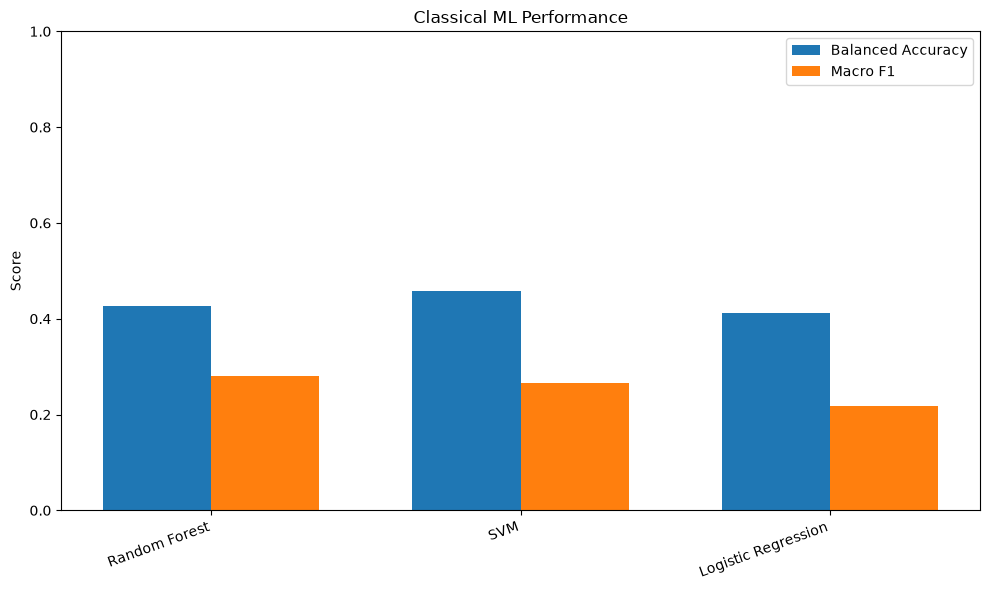

Saved: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/classical_ml/classical_ml_performance_comparison.png


In [27]:
plt.figure(figsize=(10, 6))

x = np.arange(len(classical_comparison))
width = 0.35

plt.bar(
    x - width / 2,
    classical_comparison["Balanced Accuracy"],
    width,
    label="Balanced Accuracy"
)

plt.bar(
    x + width / 2,
    classical_comparison["Macro F1"],
    width,
    label="Macro F1"
)

plt.xticks(
    x,
    classical_comparison["Model"],
    rotation=20,
    ha="right"
)

plt.ylabel("Score")
plt.title("Classical ML Performance")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

classical_plot_path = (
    CLASSICAL_DIR / "classical_ml_performance_comparison.png"
)

plt.savefig(classical_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", classical_plot_path)

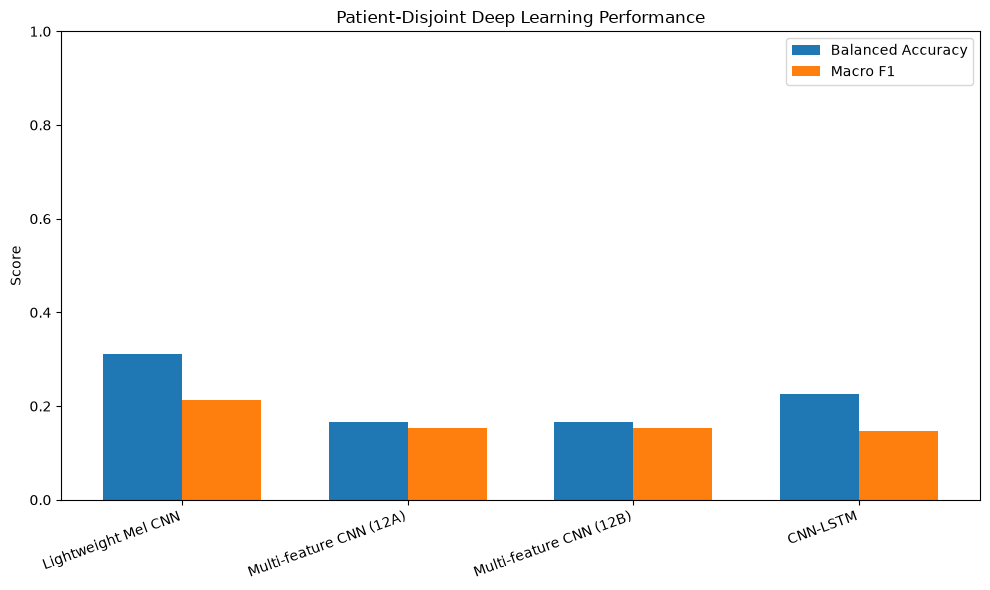

Saved: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/deep_learning_performance_comparison.png


In [28]:
plt.figure(figsize=(10, 6))

x = np.arange(len(dl_results))
width = 0.35

plt.bar(
    x - width / 2,
    dl_results["Balanced Accuracy"],
    width,
    label="Balanced Accuracy"
)

plt.bar(
    x + width / 2,
    dl_results["Macro F1"],
    width,
    label="Macro F1"
)

plt.xticks(
    x,
    dl_results["Model"],
    rotation=20,
    ha="right"
)

plt.ylabel("Score")
plt.title("Patient-Disjoint Deep Learning Performance")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

dl_plot_path = (
    DL_DIR / "deep_learning_performance_comparison.png"
)

plt.savefig(dl_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", dl_plot_path)

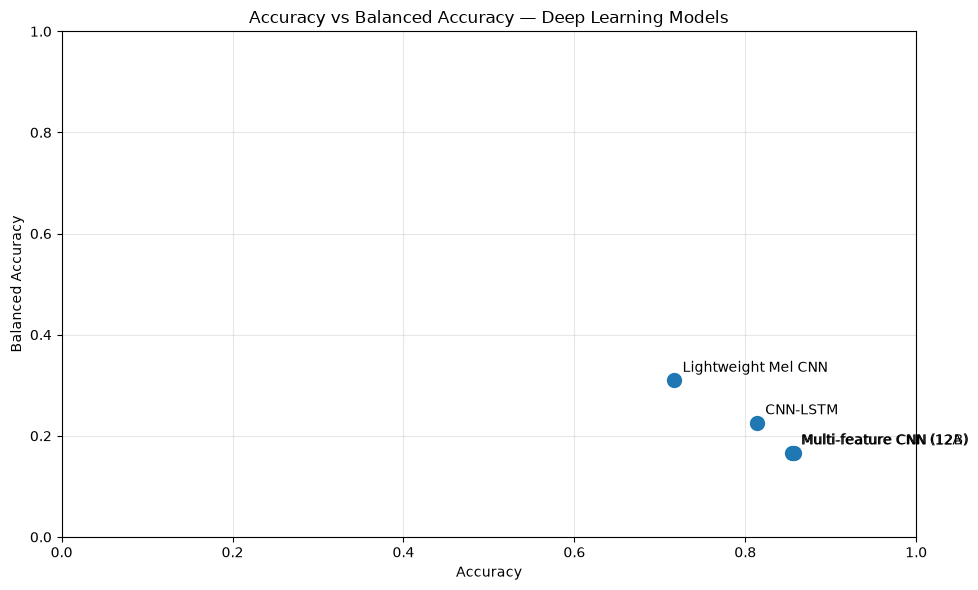

Saved: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/accuracy_vs_balanced_accuracy.png


In [29]:
plt.figure(figsize=(10, 6))

plt.scatter(
    dl_results["Accuracy"],
    dl_results["Balanced Accuracy"],
    s=100
)

for _, row in dl_results.iterrows():
    plt.annotate(
        row["Model"],
        (row["Accuracy"], row["Balanced Accuracy"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Accuracy")
plt.ylabel("Balanced Accuracy")
plt.title("Accuracy vs Balanced Accuracy — Deep Learning Models")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()

accuracy_plot_path = (
    DL_DIR / "accuracy_vs_balanced_accuracy.png"
)

plt.savefig(
    accuracy_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", accuracy_plot_path)

In [30]:
classical_comparison_path = (
    CLASSICAL_DIR / "final_classical_ml_comparison.csv"
)

dl_comparison_path = (
    DL_DIR / "final_deep_learning_comparison.csv"
)

patient_comparison_path = (
    PATIENT_DIR / "final_patient_level_comparison.csv"
)

classical_comparison.to_csv(
    classical_comparison_path,
    index=False
)

dl_results.to_csv(
    dl_comparison_path,
    index=False
)

patient_comparison_df.to_csv(
    patient_comparison_path,
    index=False
)

print("Saved:")
print(classical_comparison_path)
print(dl_comparison_path)
print(patient_comparison_path)

Saved:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/classical_ml/final_classical_ml_comparison.csv
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/final_deep_learning_comparison.csv
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/patient_level_prediction/final_patient_level_comparison.csv


In [31]:
best_classical_macro_f1 = classical_ranked.iloc[0]["Model"]
best_classical_balanced = classical_comparison.loc[
    classical_comparison["Balanced Accuracy"].idxmax(),
    "Model"
]

best_dl_macro_f1 = dl_ranked.iloc[0]["Model"]
best_dl_balanced = dl_results.loc[
    dl_results["Balanced Accuracy"].idxmax(),
    "Model"
]

best_patient_model = patient_ranked.iloc[0]["aggregation_method"]

final_summary = {
    "best_classical_by_macro_f1": best_classical_macro_f1,
    "best_classical_by_balanced_accuracy": best_classical_balanced,
    "best_deep_learning_by_macro_f1": best_dl_macro_f1,
    "best_deep_learning_by_balanced_accuracy": best_dl_balanced,
    "best_patient_level_aggregation": best_patient_model,
    "primary_final_deep_learning_model": "Lightweight Mel CNN"
}

print(json.dumps(final_summary, indent=2))

{
  "best_classical_by_macro_f1": "Random Forest",
  "best_classical_by_balanced_accuracy": "SVM",
  "best_deep_learning_by_macro_f1": "Lightweight Mel CNN",
  "best_deep_learning_by_balanced_accuracy": "Lightweight Mel CNN",
  "best_patient_level_aggregation": "Majority Vote",
  "primary_final_deep_learning_model": "Lightweight Mel CNN"
}


In [32]:
best_classical_macro_f1 = classical_ranked.iloc[0]["Model"]
best_classical_balanced = classical_comparison.loc[
    classical_comparison["Balanced Accuracy"].idxmax(),
    "Model"
]

best_dl_macro_f1 = dl_ranked.iloc[0]["Model"]
best_dl_balanced = dl_results.loc[
    dl_results["Balanced Accuracy"].idxmax(),
    "Model"
]

best_patient_model = patient_ranked.iloc[0]["aggregation_method"]

final_summary = {
    "best_classical_by_macro_f1": best_classical_macro_f1,
    "best_classical_by_balanced_accuracy": best_classical_balanced,
    "best_deep_learning_by_macro_f1": best_dl_macro_f1,
    "best_deep_learning_by_balanced_accuracy": best_dl_balanced,
    "best_patient_level_aggregation": best_patient_model,
    "primary_final_deep_learning_model": "Lightweight Mel CNN"
}

print(json.dumps(final_summary, indent=2))

{
  "best_classical_by_macro_f1": "Random Forest",
  "best_classical_by_balanced_accuracy": "SVM",
  "best_deep_learning_by_macro_f1": "Lightweight Mel CNN",
  "best_deep_learning_by_balanced_accuracy": "Lightweight Mel CNN",
  "best_patient_level_aggregation": "Majority Vote",
  "primary_final_deep_learning_model": "Lightweight Mel CNN"
}


In [33]:
FINAL_SUMMARY_PATH = (
    DL_DIR / "final_model_comparison_summary.json"
)

with open(FINAL_SUMMARY_PATH, "w") as f:
    json.dump(
        final_summary,
        f,
        indent=4
    )

print("Saved:", FINAL_SUMMARY_PATH)

Saved: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/final_model_comparison_summary.json


# Final Experimental Conclusion

## 1. Classical Machine Learning

Logistic Regression, SVM, and Random Forest were evaluated using the
official ICBHI cycle-level test split.

The classical experiments demonstrate that traditional machine-learning
models can achieve relatively strong overall performance on the dominant
disease class. However, the imbalance-aware metrics reveal substantially
lower performance across the complete disease distribution.

Random Forest provides strong overall performance and is an important
classical baseline, while SVM provides the highest balanced accuracy among
the classical models.

---

## 2. Deep Learning

Four deep-learning architectures were evaluated using a patient-disjoint
test split:

- Lightweight Mel CNN
- Multi-feature CNN (12A)
- Multi-feature CNN (12B)
- CNN-LSTM

The Lightweight Mel CNN provides the strongest balance between overall
performance and minority-class performance.

Although the multi-feature CNN models achieve higher raw accuracy, their
balanced accuracy and macro F1 are considerably lower. This indicates that
their high accuracy is strongly influenced by the dominant COPD class.

The CNN-LSTM architecture does not provide an improvement over the
Lightweight Mel CNN on the primary imbalance-aware metrics.

---

## 3. Patient-Level Prediction

Because respiratory disease is fundamentally a patient-level target,
cycle-level predictions were aggregated to obtain a final prediction for
each patient.

Both majority-vote and probability-based aggregation were investigated.

This provides a more clinically meaningful evaluation level than treating
each respiratory cycle as an independent patient.

---

## 4. Final Model

The Lightweight Mel CNN is selected as the primary deep-learning model
because it provides the strongest patient-disjoint cycle-level performance
according to balanced accuracy and macro F1.

The same model is subsequently used for patient-level prediction and
explainability analysis.

---

## 5. Data Mining Contribution

The project incorporates multiple Data Mining concepts:

- Data cleaning and quality validation
- Exploratory Data Analysis
- Feature engineering
- Feature correlation analysis
- ANOVA feature scoring
- Mutual information
- Random Forest feature importance
- Feature selection
- PCA
- K-Means clustering
- Classical machine learning
- Imbalanced classification evaluation
- Patient-disjoint validation
- Deep-learning classification
- Patient-level aggregation
- Explainable AI / Grad-CAM
- Comparative model evaluation

The final analysis therefore evaluates not only predictive accuracy but also
feature relevance, data structure, generalization, class imbalance, and
model interpretability.

In [34]:
print("FINAL MODEL COMPARISON COMPLETE")
print("=" * 60)

print("\nClassical ML:")
display(classical_ranked)

print("\nDeep Learning:")
display(dl_ranked)

print("\nPatient Level:")
display(patient_ranked)

print("\nPrimary final model:")
print("Lightweight Mel CNN")

print("\nSaved summary:")
print(FINAL_SUMMARY_PATH)

FINAL MODEL COMPARISON COMPLETE

Classical ML:


,Rank,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC AUC (Macro)
0,1,Random Forest,0.874456,0.426495,0.370614,0.266559,0.279604,0.877536,NaN
1,2,SVM,0.806604,0.458256,0.260503,0.286410,0.265580,0.847078,NaN
2,3,Logistic Regression,0.641509,0.411920,0.233807,0.257450,0.218218,0.745795,NaN



Deep Learning:


,Rank,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,1,Lightweight Mel CNN,0.716848,0.310168,0.213023,0.265858,0.212880,0.768721
1,2,Multi-feature CNN (12B),0.856502,0.166667,0.142750,0.166667,0.153784,0.790299
2,3,Multi-feature CNN (12A),0.855221,0.166417,0.142720,0.166417,0.153660,0.789662
3,4,CNN-LSTM,0.813581,0.226085,0.134473,0.169564,0.146471,0.786735



Patient Level:


,Rank,rank,aggregation_method,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,1,Majority Vote,0.56,0.333333,0.132812,0.25,0.162069,0.482207
1,2,2,Mean Probability,0.56,0.333333,0.132812,0.25,0.162069,0.482207



Primary final model:
Lightweight Mel CNN

Saved summary:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/final_model_comparison_summary.json
